# 📈 02 — Analisi Quantitativa: Trend Temporali, Finanziari e Settoriali

Questo notebook approfondisce l'analisi **quantitativa** degli aiuti di stato italiani classificati AI/NON_AI.

**Obiettivi:**
1. Trend temporali della proporzione AI
2. Evoluzione degli importi finanziari AI
3. Concentrazione finanziaria (Curva di Lorenz, Indice di Gini)
4. Analisi settoriale (codici ATECO)
5. Analisi regionale quantitativa (heatmap)
6. Tipo di beneficiario (PMI vs Grandi Imprese)

## 1. Setup e Caricamento Dati

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data')
YEARS = list(range(2014, 2026))

COLS_TO_LOAD = [
    'TITOLO_MISURA', 'DES_TIPO_MISURA',
    'DATA_CONCESSIONE', 'DENOMINAZIONE_BENEFICIARIO',
    'DES_TIPO_BENEFICIARIO', 'REGIONE_BENEFICIARIO',
    'IMPORTO_NOMINALE_TOTALE', 'ELEMENTO_DI_AIUTO_TOTALE',
    'SETTORI_ATTIVITA', 'CLASSIFICAZIONE', 'CLASSIFICAZIONE_CONFIDENZA',
    'CLASSIFICAZIONE_MULTICLASS', 'CLASSIFICAZIONE_MULTICLASS_CONFIDENZA'
]

MULTICLASS_CATEGORIES = [
    "Enterprise",
    "Automotive, Robotics, Industry",
    "Environment",
    "Research & Generic use",
    "Fintech and Marketing",
    "Healthcare AI",
    "Media & Entertainment",
]
MULTICLASS_PALETTE = sns.color_palette("tab10", n_colors=len(MULTICLASS_CATEGORIES))
MULTICLASS_COLOR_MAP = dict(zip(MULTICLASS_CATEGORIES, MULTICLASS_PALETTE))

print('Setup completato ✓')

Setup completato ✓


In [2]:
# Caricamento dati
frames = []
for year in YEARS:
    filepath = DATA_DIR / f'classified_multiclass_aiuti_{year}.csv'
    if filepath.exists():
        print(f'Caricamento {year}...', end=' ')
        chunks = []
        for chunk in pd.read_csv(filepath, usecols=COLS_TO_LOAD, chunksize=100_000, low_memory=False):
            chunks.append(chunk)
        df_year = pd.concat(chunks, ignore_index=True)
        df_year['ANNO'] = year
        print(f'{len(df_year):>12,} righe')
        frames.append(df_year)

df = pd.concat(frames, ignore_index=True)
del frames

# Conversioni
df['IMPORTO_NOMINALE_TOTALE'] = pd.to_numeric(df['IMPORTO_NOMINALE_TOTALE'], errors='coerce')
df['ELEMENTO_DI_AIUTO_TOTALE'] = pd.to_numeric(df['ELEMENTO_DI_AIUTO_TOTALE'], errors='coerce')
df['CLASSIFICAZIONE_MULTICLASS_CONFIDENZA'] = pd.to_numeric(df['CLASSIFICAZIONE_MULTICLASS_CONFIDENZA'], errors='coerce')

# Estrai la sezione ATECO (prima lettera del codice attività)
df['SETTORI_ATTIVITA'] = df['SETTORI_ATTIVITA'].astype(str).str.split('|')
df = df.explode('SETTORI_ATTIVITA')
df['REGIONE_BENEFICIARIO'] = df['REGIONE_BENEFICIARIO'].astype(str).str.split('|')
df = df.explode('REGIONE_BENEFICIARIO')

df['SETTORE_MACRO'] = df['SETTORI_ATTIVITA'].astype(str).str[0].str.upper()

print(f'\n✅ Totale: {len(df):,} righe caricate')

# --- Sanity check multiclass ---
df_ai_check = df[df['CLASSIFICAZIONE'] == 'AI']
mc_populated = df_ai_check['CLASSIFICAZIONE_MULTICLASS'].notna().sum()
mc_total = len(df_ai_check)
mc_dist = df_ai_check['CLASSIFICAZIONE_MULTICLASS'].value_counts()
print(f'\nSanity check CLASSIFICAZIONE_MULTICLASS:')
print(f'  Record AI totali       : {mc_total:,}')
print(f'  Con multiclass popolata: {mc_populated:,} ({mc_populated/mc_total*100:.1f}%)')
print(f'\nDistribuzione categorie multiclass (record AI):')
print(mc_dist.to_string())
missing_cats = set(MULTICLASS_CATEGORIES) - set(mc_dist.index)
if missing_cats:
    print(f'\n⚠️  Categorie assenti nel dataset: {missing_cats}')
else:
    print('\n✅ Tutte le 7 categorie presenti.')

Caricamento 2014...       15,448 righe
Caricamento 2015...        2,299 righe
Caricamento 2016...        8,378 righe
Caricamento 2017...      214,546 righe
Caricamento 2018...      685,622 righe
Caricamento 2019...      514,265 righe
Caricamento 2020...    2,669,916 righe
Caricamento 2021...    3,221,074 righe
Caricamento 2022...    2,062,853 righe
Caricamento 2023...    6,478,711 righe
Caricamento 2024...    6,022,284 righe
Caricamento 2025...    2,061,972 righe

✅ Totale: 23,962,273 righe caricate

Sanity check CLASSIFICAZIONE_MULTICLASS:
  Record AI totali       : 13,952
  Con multiclass popolata: 13,952 (100.0%)

Distribuzione categorie multiclass (record AI):
CLASSIFICAZIONE_MULTICLASS
Enterprise                        6180
Automotive, Robotics, Industry    2025
Healthcare AI                     1496
Environment                       1340
Media & Entertainment             1131
Research & Generic use            1048
Fintech and Marketing              732

✅ Tutte le 7 categorie pre

## 2. Trend Temporali della Proporzione AI

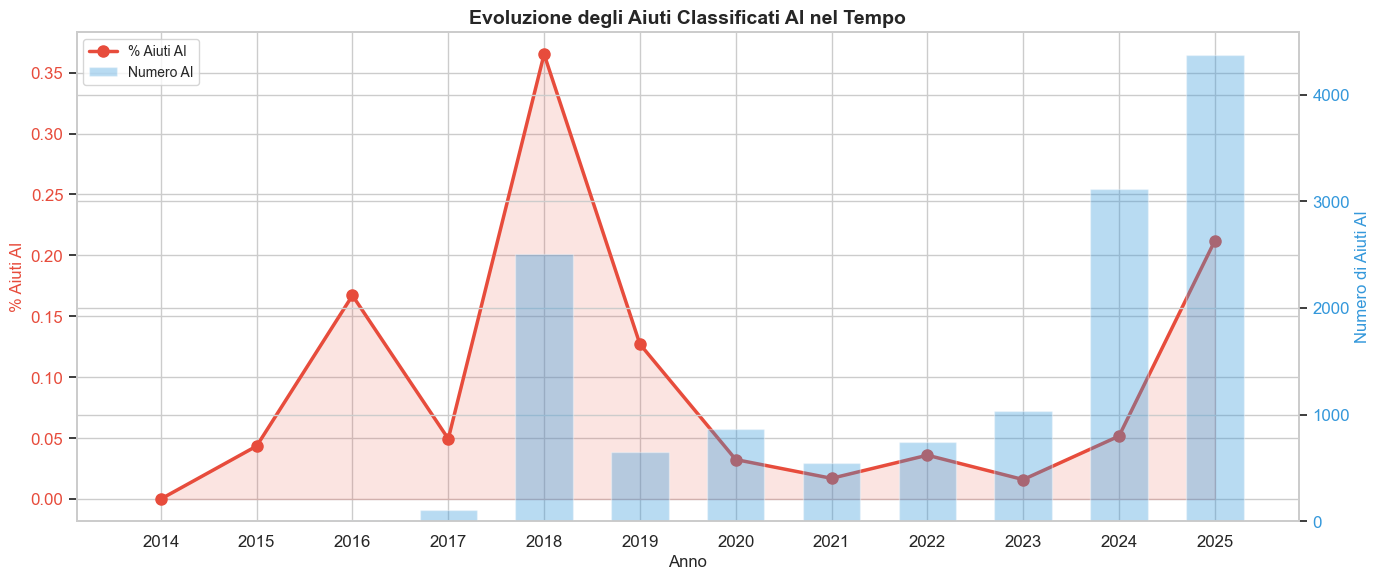

,ANNO,pct_ai,num_ai
0,2014,0.0000,0.0
1,2015,0.0435,1.0
2,2016,0.1671,14.0
3,2017,0.0494,106.0
4,2018,0.3652,2504.0
5,2019,0.1272,654.0
6,2020,0.0324,865.0
7,2021,0.0170,547.0
8,2022,0.0360,742.0
9,2023,0.0160,1034.0


In [3]:
# Calcola proporzione AI per anno
trend = df.groupby('ANNO')['CLASSIFICAZIONE'].apply(
    lambda x: (x == 'AI').sum() / len(x) * 100
).reset_index(name='pct_ai')

# Numero assoluto di AI per anno
ai_counts = df[df['CLASSIFICAZIONE'] == 'AI'].groupby('ANNO').size().reset_index(name='num_ai')
trend = trend.merge(ai_counts, on='ANNO', how='left').fillna(0)

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = '#e74c3c'
ax1.plot(trend['ANNO'], trend['pct_ai'], marker='o', linewidth=2.5, color=color1, 
         markersize=8, label='% Aiuti AI', zorder=5)
ax1.fill_between(trend['ANNO'], trend['pct_ai'], alpha=0.15, color=color1)
ax1.set_xlabel('Anno', fontsize=12)
ax1.set_ylabel('% Aiuti AI', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(YEARS)

ax2 = ax1.twinx()
color2 = '#3498db'
ax2.bar(trend['ANNO'], trend['num_ai'], alpha=0.35, color=color2, label='Numero AI', width=0.6)
ax2.set_ylabel('Numero di Aiuti AI', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)

# Legenda combinata
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Evoluzione degli Aiuti Classificati AI nel Tempo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabella
trend.round(4)

### 2.1 Trend Temporale per Categoria Multiclass

Percentuale di ciascuna delle 7 categorie multiclass sul totale degli aiuti AI, per anno.

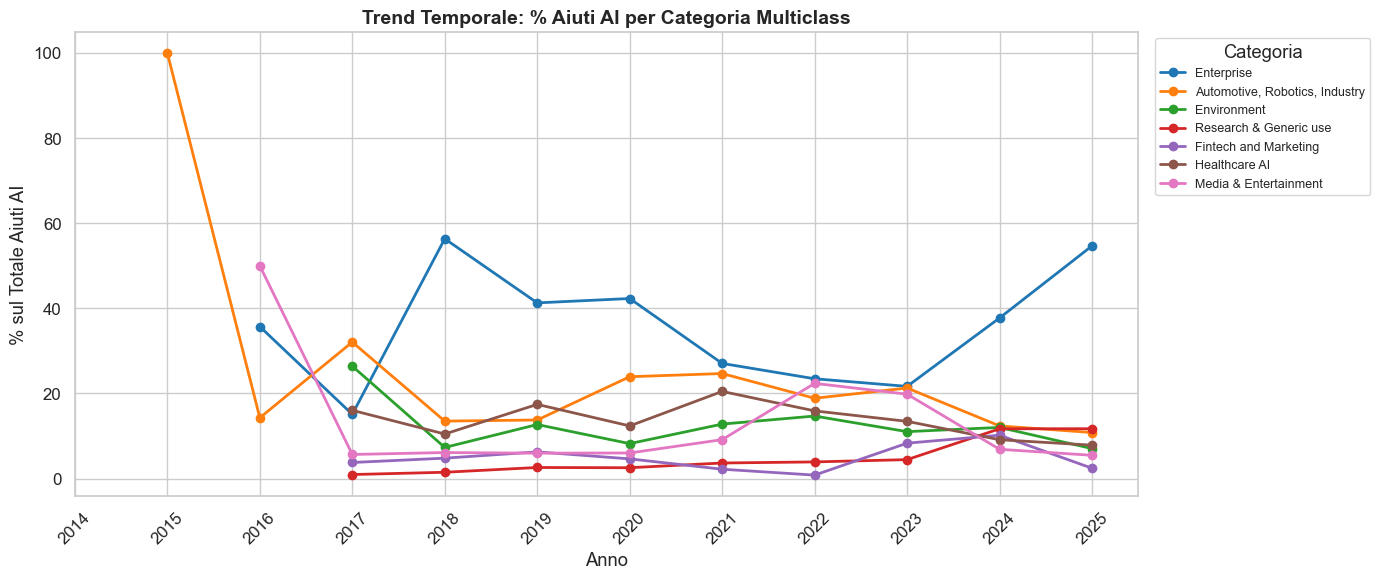

In [4]:
# Trend per categoria multiclass — % sul totale AI per anno
df_ai = df[df['CLASSIFICAZIONE'] == 'AI'].copy()

mc_trend = (
    df_ai.groupby(['ANNO', 'CLASSIFICAZIONE_MULTICLASS'])
    .size()
    .reset_index(name='count')
)
ai_per_anno = df_ai.groupby('ANNO').size().reset_index(name='tot_ai')
mc_trend = mc_trend.merge(ai_per_anno, on='ANNO')
mc_trend['pct'] = mc_trend['count'] / mc_trend['tot_ai'] * 100

fig, ax = plt.subplots(figsize=(14, 6))

for cat in MULTICLASS_CATEGORIES:
    subset = mc_trend[mc_trend['CLASSIFICAZIONE_MULTICLASS'] == cat]
    if subset.empty:
        continue
    ax.plot(
        subset['ANNO'], subset['pct'],
        marker='o', linewidth=2, markersize=6,
        color=MULTICLASS_COLOR_MAP[cat], label=cat
    )

ax.set_title('Trend Temporale: % Aiuti AI per Categoria Multiclass', fontsize=14, fontweight='bold')
ax.set_xlabel('Anno')
ax.set_ylabel('% sul Totale Aiuti AI')
ax.set_xticks(YEARS)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Categoria', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Evoluzione degli Importi Finanziari AI

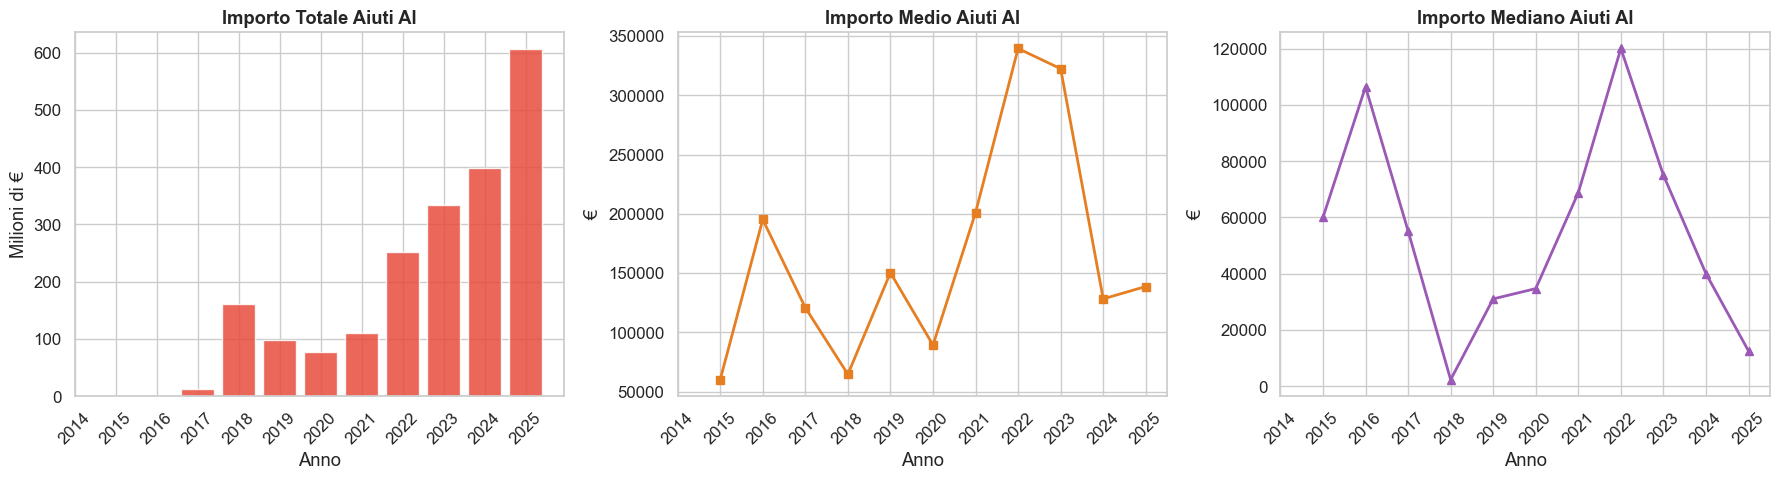

In [5]:
# Importi per anno — solo AI
df_ai = df[df['CLASSIFICAZIONE'] == 'AI'].copy()

fin_ai = df_ai.groupby('ANNO')['IMPORTO_NOMINALE_TOTALE'].agg(
    ['sum', 'mean', 'median', 'count']
).rename(columns={'sum': 'totale', 'mean': 'media', 'median': 'mediana', 'count': 'n'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Importo totale AI
axes[0].bar(fin_ai.index, fin_ai['totale'] / 1e6, color='#e74c3c', edgecolor='white', alpha=0.85)
axes[0].set_title('Importo Totale Aiuti AI', fontweight='bold')
axes[0].set_xlabel('Anno')
axes[0].set_ylabel('Milioni di €')
axes[0].set_xticks(YEARS)
axes[0].tick_params(axis='x', rotation=45)

# Importo medio AI
axes[1].plot(fin_ai.index, fin_ai['media'], marker='s', linewidth=2, color='#e67e22')
axes[1].set_title('Importo Medio Aiuti AI', fontweight='bold')
axes[1].set_xlabel('Anno')
axes[1].set_ylabel('€')
axes[1].set_xticks(YEARS)
axes[1].tick_params(axis='x', rotation=45)

# Importo mediano AI
axes[2].plot(fin_ai.index, fin_ai['mediana'], marker='^', linewidth=2, color='#9b59b6')
axes[2].set_title('Importo Mediano Aiuti AI', fontweight='bold')
axes[2].set_xlabel('Anno')
axes[2].set_ylabel('€')
axes[2].set_xticks(YEARS)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

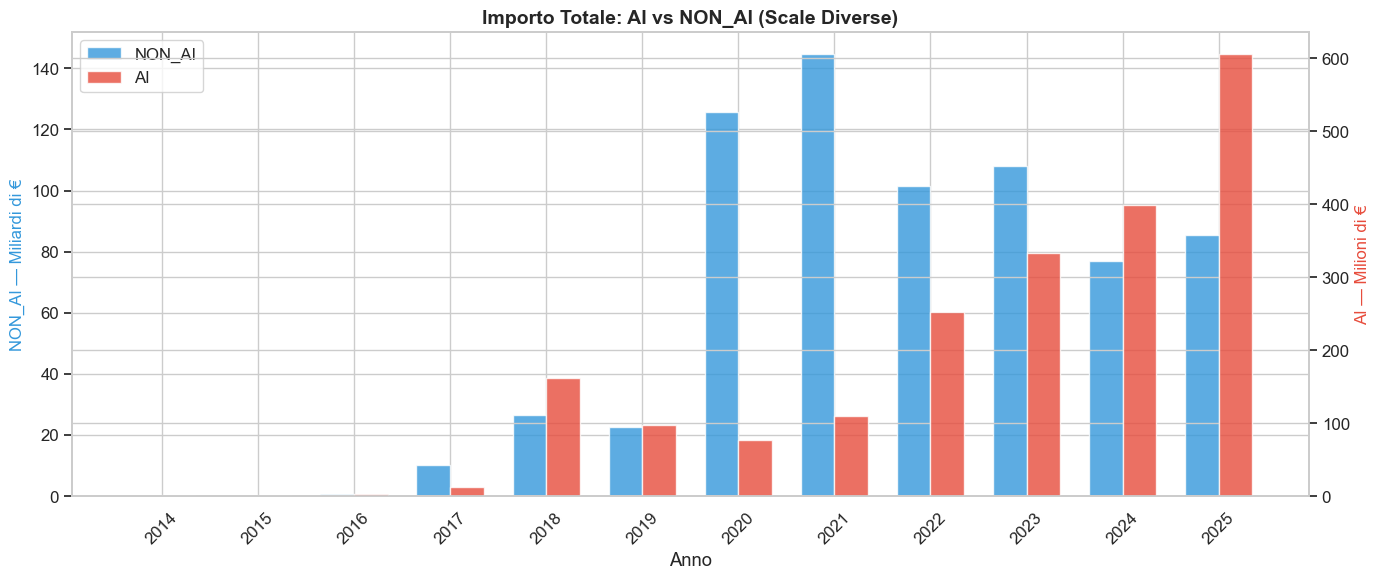

In [6]:
# Confronto importo totale AI vs NON_AI su doppio asse (scala diversa)
fin_both = df.groupby(['ANNO', 'CLASSIFICAZIONE'])['IMPORTO_NOMINALE_TOTALE'].sum().unstack(fill_value=0)

fig, ax1 = plt.subplots(figsize=(14, 6))

x = np.arange(len(YEARS))
width = 0.35

if 'NON_AI' in fin_both.columns:
    ax1.bar(x - width/2, fin_both['NON_AI'] / 1e9, width, label='NON_AI', color='#3498db', alpha=0.8)
    ax1.set_ylabel('NON_AI — Miliardi di €', color='#3498db', fontsize=12)

ax2 = ax1.twinx()
if 'AI' in fin_both.columns:
    ax2.bar(x + width/2, fin_both['AI'] / 1e6, width, label='AI', color='#e74c3c', alpha=0.8)
    ax2.set_ylabel('AI — Milioni di €', color='#e74c3c', fontsize=12)

ax1.set_xlabel('Anno')
ax1.set_xticks(x)
ax1.set_xticklabels(YEARS, rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Importo Totale: AI vs NON_AI (Scale Diverse)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.1 Importo Totale AI per Categoria Multiclass e Anno

Stacked bar: ogni anno è suddiviso per categoria multiclass (somma `IMPORTO_NOMINALE_TOTALE` in M€).

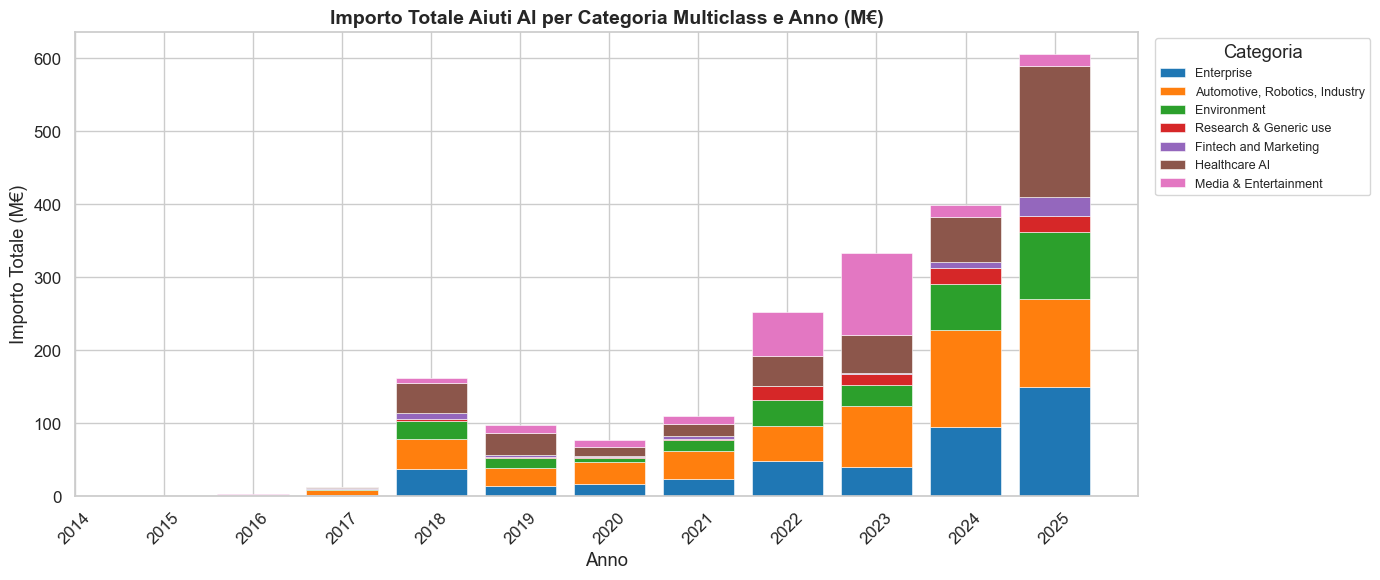

In [7]:
# Stacked bar: importo totale AI per anno × categoria multiclass (M€)
mc_importi = df_ai.pivot_table(
    index='ANNO',
    columns='CLASSIFICAZIONE_MULTICLASS',
    values='IMPORTO_NOMINALE_TOTALE',
    aggfunc='sum',
    fill_value=0
) / 1e6  # converti in M€

# Riordina colonne secondo ordine canonico (solo quelle presenti)
ordered_cols = [c for c in MULTICLASS_CATEGORIES if c in mc_importi.columns]
mc_importi = mc_importi[ordered_cols]

fig, ax = plt.subplots(figsize=(14, 6))
bottom = np.zeros(len(mc_importi))

for cat in ordered_cols:
    vals = mc_importi[cat].values
    ax.bar(
        mc_importi.index, vals,
        bottom=bottom,
        label=cat,
        color=MULTICLASS_COLOR_MAP[cat],
        edgecolor='white',
        linewidth=0.4
    )
    bottom += vals

ax.set_title('Importo Totale Aiuti AI per Categoria Multiclass e Anno (M€)', fontsize=14, fontweight='bold')
ax.set_xlabel('Anno')
ax.set_ylabel('Importo Totale (M€)')
ax.set_xticks(YEARS)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Categoria', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Concentrazione Finanziaria — Curva di Lorenz e Gini

In [8]:
def gini_coefficient(values):
    """Calcola il coefficiente di Gini di un array di valori."""
    values = np.sort(values[values > 0])  # escludi zeri
    n = len(values)
    if n == 0:
        return 0
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * values) - (n + 1) * np.sum(values)) / (n * np.sum(values))


def lorenz_curve(values):
    """Restituisce le coordinate per la curva di Lorenz."""
    values = np.sort(values[values > 0])
    cum_values = np.cumsum(values) / np.sum(values)
    cum_pop = np.arange(1, len(values) + 1) / len(values)
    return np.concatenate([[0], cum_pop]), np.concatenate([[0], cum_values])

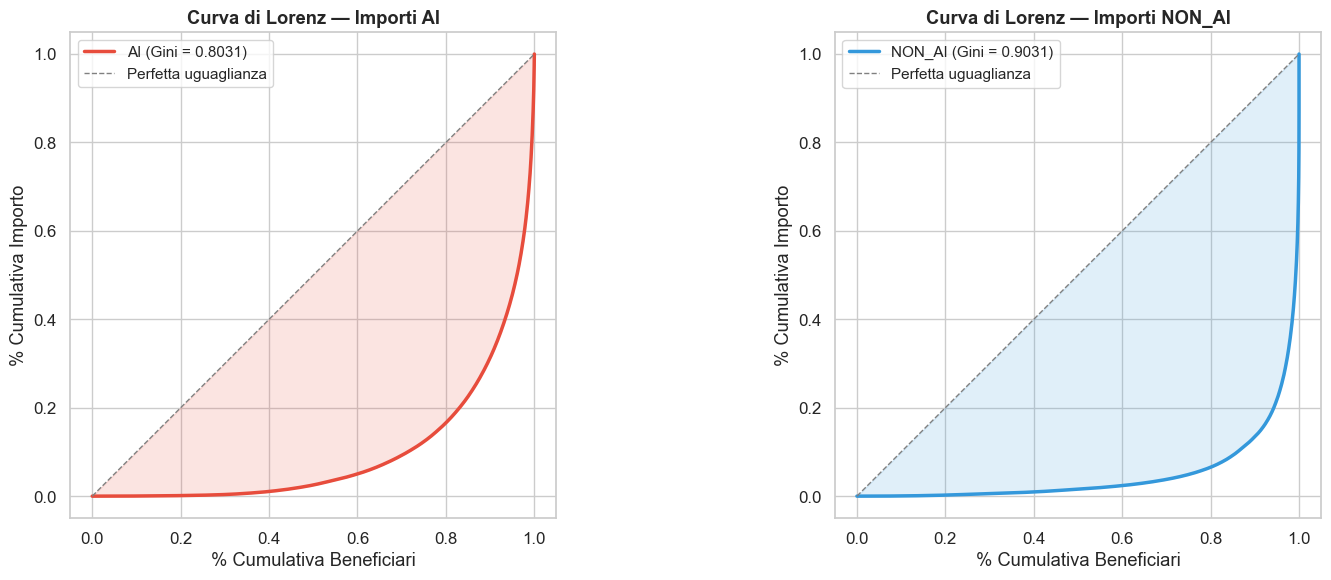

Indice di Gini — AI:     0.8031
Indice di Gini — NON_AI: 0.9031


In [9]:
# Curva di Lorenz per importi AI
ai_importi = df_ai['IMPORTO_NOMINALE_TOTALE'].dropna().values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# AI
x_ai, y_ai = lorenz_curve(ai_importi)
gini_ai = gini_coefficient(ai_importi)
axes[0].plot(x_ai, y_ai, linewidth=2.5, color='#e74c3c', label=f'AI (Gini = {gini_ai:.4f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='Perfetta uguaglianza')
axes[0].fill_between(x_ai, y_ai, x_ai, alpha=0.15, color='#e74c3c')
axes[0].set_title('Curva di Lorenz — Importi AI', fontweight='bold')
axes[0].set_xlabel('% Cumulativa Beneficiari')
axes[0].set_ylabel('% Cumulativa Importo')
axes[0].legend(fontsize=11)
axes[0].set_aspect('equal')

# NON_AI
nonai_importi = df[df['CLASSIFICAZIONE'] == 'NON_AI']['IMPORTO_NOMINALE_TOTALE'].dropna().values
x_na, y_na = lorenz_curve(nonai_importi)
gini_na = gini_coefficient(nonai_importi)
axes[1].plot(x_na, y_na, linewidth=2.5, color='#3498db', label=f'NON_AI (Gini = {gini_na:.4f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label='Perfetta uguaglianza')
axes[1].fill_between(x_na, y_na, x_na, alpha=0.15, color='#3498db')
axes[1].set_title('Curva di Lorenz — Importi NON_AI', fontweight='bold')
axes[1].set_xlabel('% Cumulativa Beneficiari')
axes[1].set_ylabel('% Cumulativa Importo')
axes[1].legend(fontsize=11)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

print(f'Indice di Gini — AI:     {gini_ai:.4f}')
print(f'Indice di Gini — NON_AI: {gini_na:.4f}')

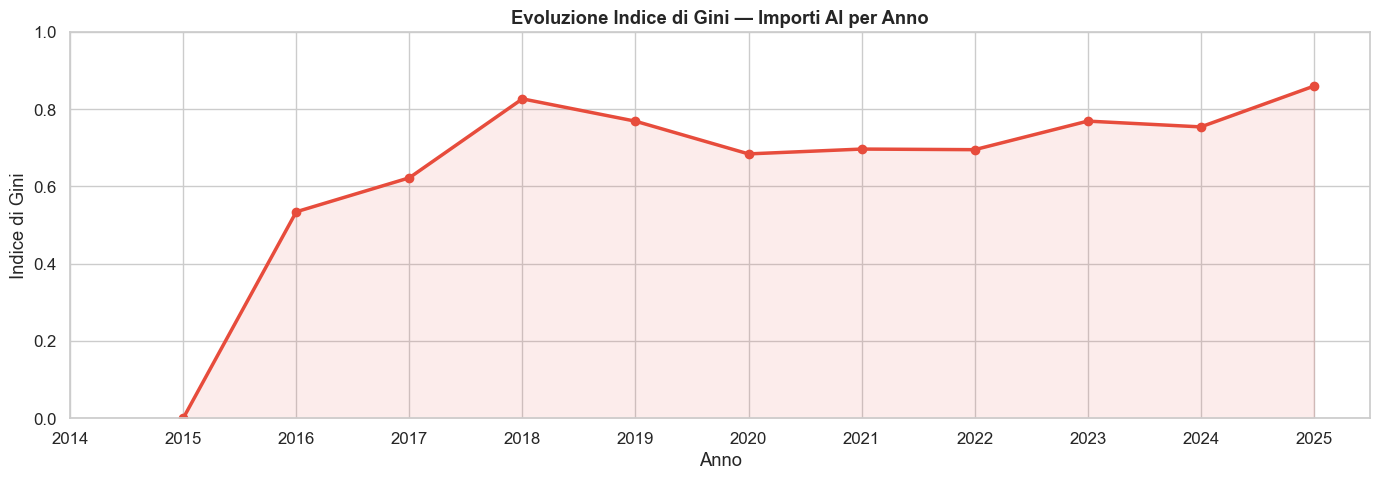

In [10]:
# Gini per anno — AI
gini_per_anno = df_ai.groupby('ANNO')['IMPORTO_NOMINALE_TOTALE'].apply(
    lambda x: gini_coefficient(x.dropna().values)
).reset_index(name='gini')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gini_per_anno['ANNO'], gini_per_anno['gini'], marker='o', linewidth=2.5, color='#e74c3c')
ax.fill_between(gini_per_anno['ANNO'], gini_per_anno['gini'], alpha=0.1, color='#e74c3c')
ax.set_title('Evoluzione Indice di Gini — Importi AI per Anno', fontweight='bold')
ax.set_xlabel('Anno')
ax.set_ylabel('Indice di Gini')
ax.set_xticks(YEARS)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### 4.1 Gini per Categoria Multiclass

Indice di Gini sugli importi `IMPORTO_NOMINALE_TOTALE` calcolato per ciascuna delle 7 categorie multiclass.
Riusa `gini_coefficient()` definita sopra.

Indice di Gini per categoria multiclass:
                     Categoria     Gini    N
         Fintech and Marketing 0.885981  732
        Research & Generic use 0.852208 1048
                    Enterprise 0.827208 6180
         Media & Entertainment 0.816132 1131
Automotive, Robotics, Industry 0.746762 2025
                 Healthcare AI 0.679560 1496
                   Environment 0.679294 1340


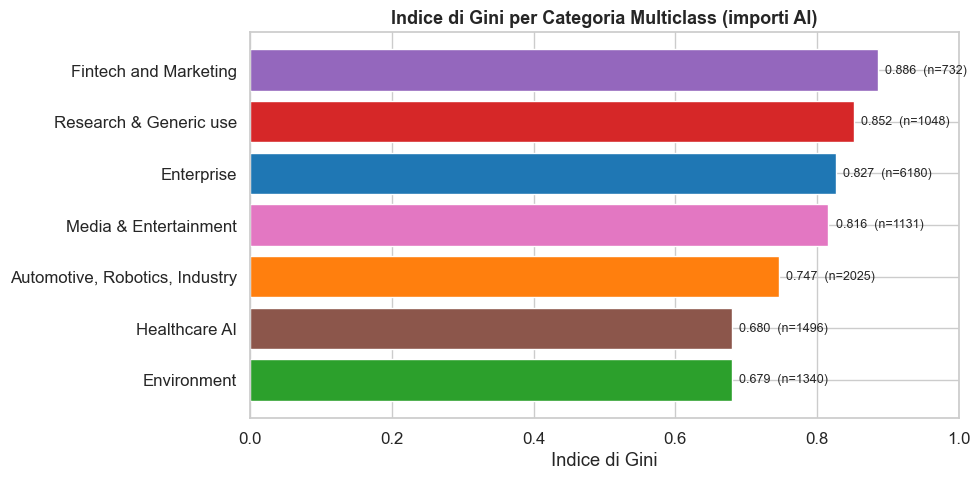

In [11]:
# Gini per categoria multiclass — riusa gini_coefficient() definita in §4
gini_per_cat = []
for cat in MULTICLASS_CATEGORIES:
    vals = (
        df_ai[df_ai['CLASSIFICAZIONE_MULTICLASS'] == cat]['IMPORTO_NOMINALE_TOTALE']
        .dropna()
        .values
    )
    g = gini_coefficient(vals) if len(vals) > 1 else np.nan
    gini_per_cat.append({'Categoria': cat, 'Gini': g, 'N': len(vals)})

gini_mc_df = pd.DataFrame(gini_per_cat).sort_values('Gini', ascending=False)

print('Indice di Gini per categoria multiclass:')
print(gini_mc_df.to_string(index=False))

# Barplot orizzontale ordinato per Gini decrescente
fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = [MULTICLASS_COLOR_MAP[c] for c in gini_mc_df['Categoria']]
ax.barh(gini_mc_df['Categoria'], gini_mc_df['Gini'], color=colors_bar, edgecolor='white')
ax.set_xlim(0, 1)
ax.set_xlabel('Indice di Gini')
ax.set_title('Indice di Gini per Categoria Multiclass (importi AI)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
for i, (g, n) in enumerate(zip(gini_mc_df['Gini'], gini_mc_df['N'])):
    ax.text(g + 0.01, i, f'{g:.3f}  (n={n})', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Analisi Settoriale (Codici ATECO)

In [12]:
# Mappatura sezioni ATECO
ATECO_SEZIONI = {
    'A': 'Agricoltura', 'B': 'Estrazione', 'C': 'Manifatturiero',
    'D': 'Energia', 'E': 'Acqua/Rifiuti', 'F': 'Costruzioni',
    'G': 'Commercio', 'H': 'Trasporti', 'I': 'Alloggio/Ristorazione',
    'J': 'Informazione/Comunicazione', 'K': 'Finanza/Assicurazioni',
    'L': 'Immobiliare', 'M': 'Attività professionali', 'N': 'Noleggio/Servizi',
    'O': 'PA', 'P': 'Istruzione', 'Q': 'Sanità', 'R': 'Arte/Intrattenimento',
    'S': 'Altri servizi', 'T': 'Famiglie', 'U': 'Organizzazioni extra-territoriali'
}

df['SETTORE_NOME'] = df['SETTORE_MACRO'].map(ATECO_SEZIONI).fillna('Altro')

In [13]:
# Distribuzione settoriale AI vs NON_AI
sett_class = df.groupby(['SETTORE_NOME', 'CLASSIFICAZIONE']).size().unstack(fill_value=0)
if 'AI' in sett_class.columns:
    sett_class['% AI'] = (sett_class['AI'] / sett_class.sum(axis=1) * 100).round(3)
    sett_class = sett_class.sort_values('AI', ascending=False)

sett_class

CLASSIFICAZIONE,AI,NON_AI,UNKNOWN,% AI
SETTORE_NOME,,,,
Altro,4931,5802117,1,0.085
Informazione/Comunicazione,2600,455324,1,0.568
Attività professionali,2419,1146493,0,0.211
Manifatturiero,1724,2664609,1,0.065
Commercio,738,4354067,1,0.017
Sanità,226,567194,0,0.040
Noleggio/Servizi,220,703898,0,0.031
Istruzione,205,212462,0,0.096
Costruzioni,179,2008733,0,0.009


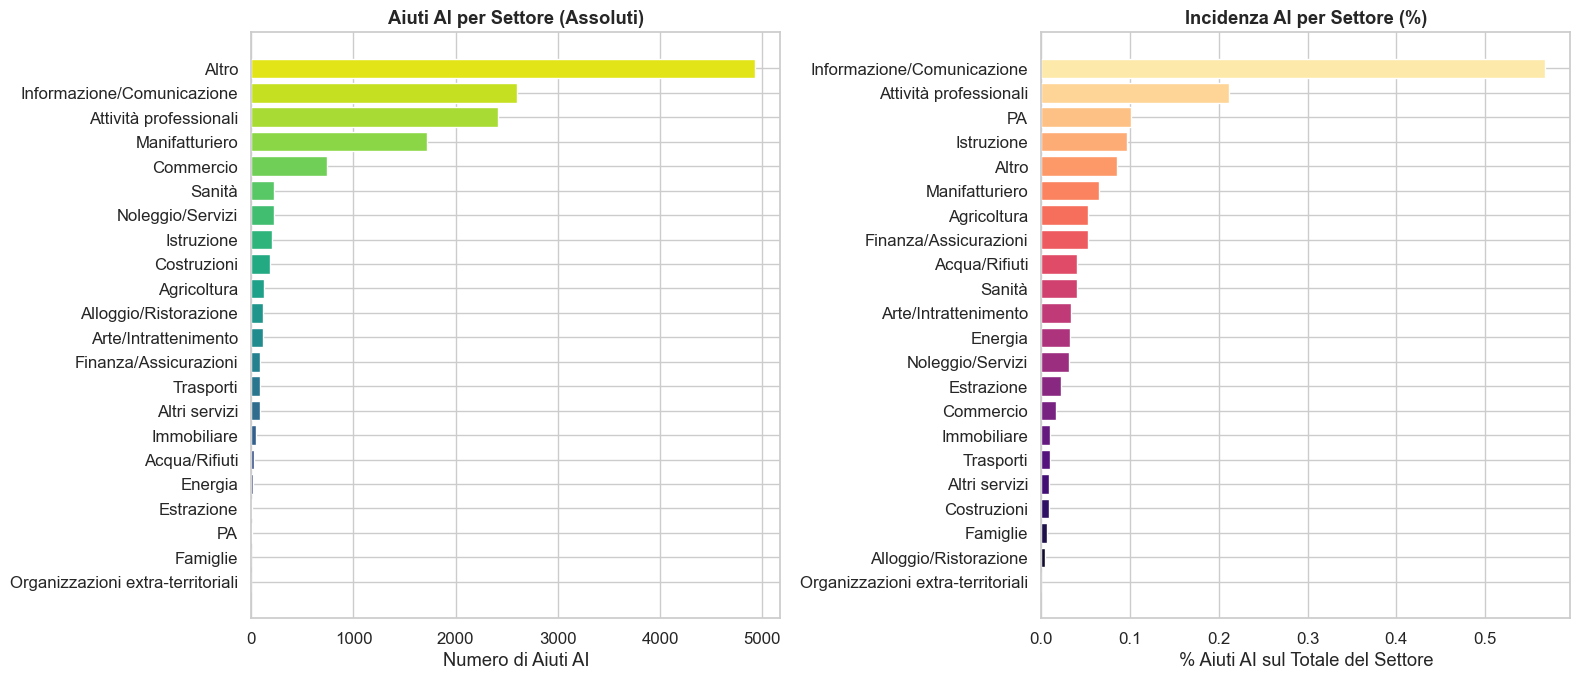

In [14]:
# Grafico: Top settori per incidenza AI
if 'AI' in sett_class.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Numero assoluto per settore
    top_sett = sett_class['AI'].sort_values(ascending=True)
    colors = sns.color_palette('viridis', len(top_sett))
    axes[0].barh(top_sett.index, top_sett.values, color=colors, edgecolor='white')
    axes[0].set_xlabel('Numero di Aiuti AI')
    axes[0].set_title('Aiuti AI per Settore (Assoluti)', fontweight='bold')
    
    # % AI per settore
    pct_sett = sett_class['% AI'].sort_values(ascending=True)
    colors2 = sns.color_palette('magma', len(pct_sett))
    axes[1].barh(pct_sett.index, pct_sett.values, color=colors2, edgecolor='white')
    axes[1].set_xlabel('% Aiuti AI sul Totale del Settore')
    axes[1].set_title('Incidenza AI per Settore (%)', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

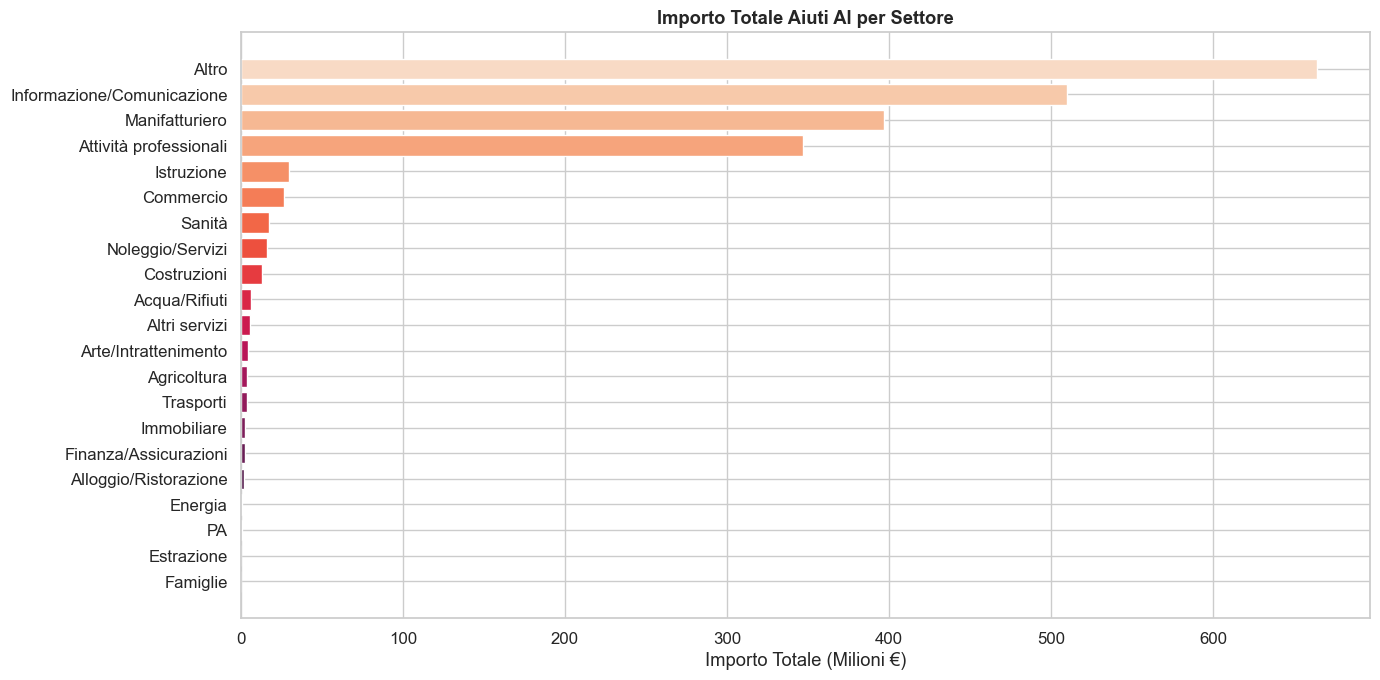

In [15]:
# Importi medi AI per settore
if len(df_ai) > 0:
    df_ai['SETTORE_NOME'] = df_ai['SETTORE_MACRO'].map(ATECO_SEZIONI).fillna('Altro')
    
    importi_settore = df_ai.groupby('SETTORE_NOME')['IMPORTO_NOMINALE_TOTALE'].agg(
        ['mean', 'median', 'sum', 'count']
    ).sort_values('sum', ascending=False)
    
    fig, ax = plt.subplots(figsize=(14, 7))
    importi_plot = importi_settore.sort_values('sum', ascending=True)
    ax.barh(importi_plot.index, importi_plot['sum'] / 1e6,
            color=sns.color_palette('rocket', len(importi_plot)), edgecolor='white')
    ax.set_xlabel('Importo Totale (Milioni €)')
    ax.set_title('Importo Totale Aiuti AI per Settore', fontweight='bold')
    plt.tight_layout()
    plt.show()

### 5.1 Heatmap ATECO × Categoria Multiclass

Conteggi (assoluti) e distribuzione normalizzata per riga (% all'interno di ogni macro-settore ATECO).
Settori e categorie con zero record AI sono esclusi per leggibilità.

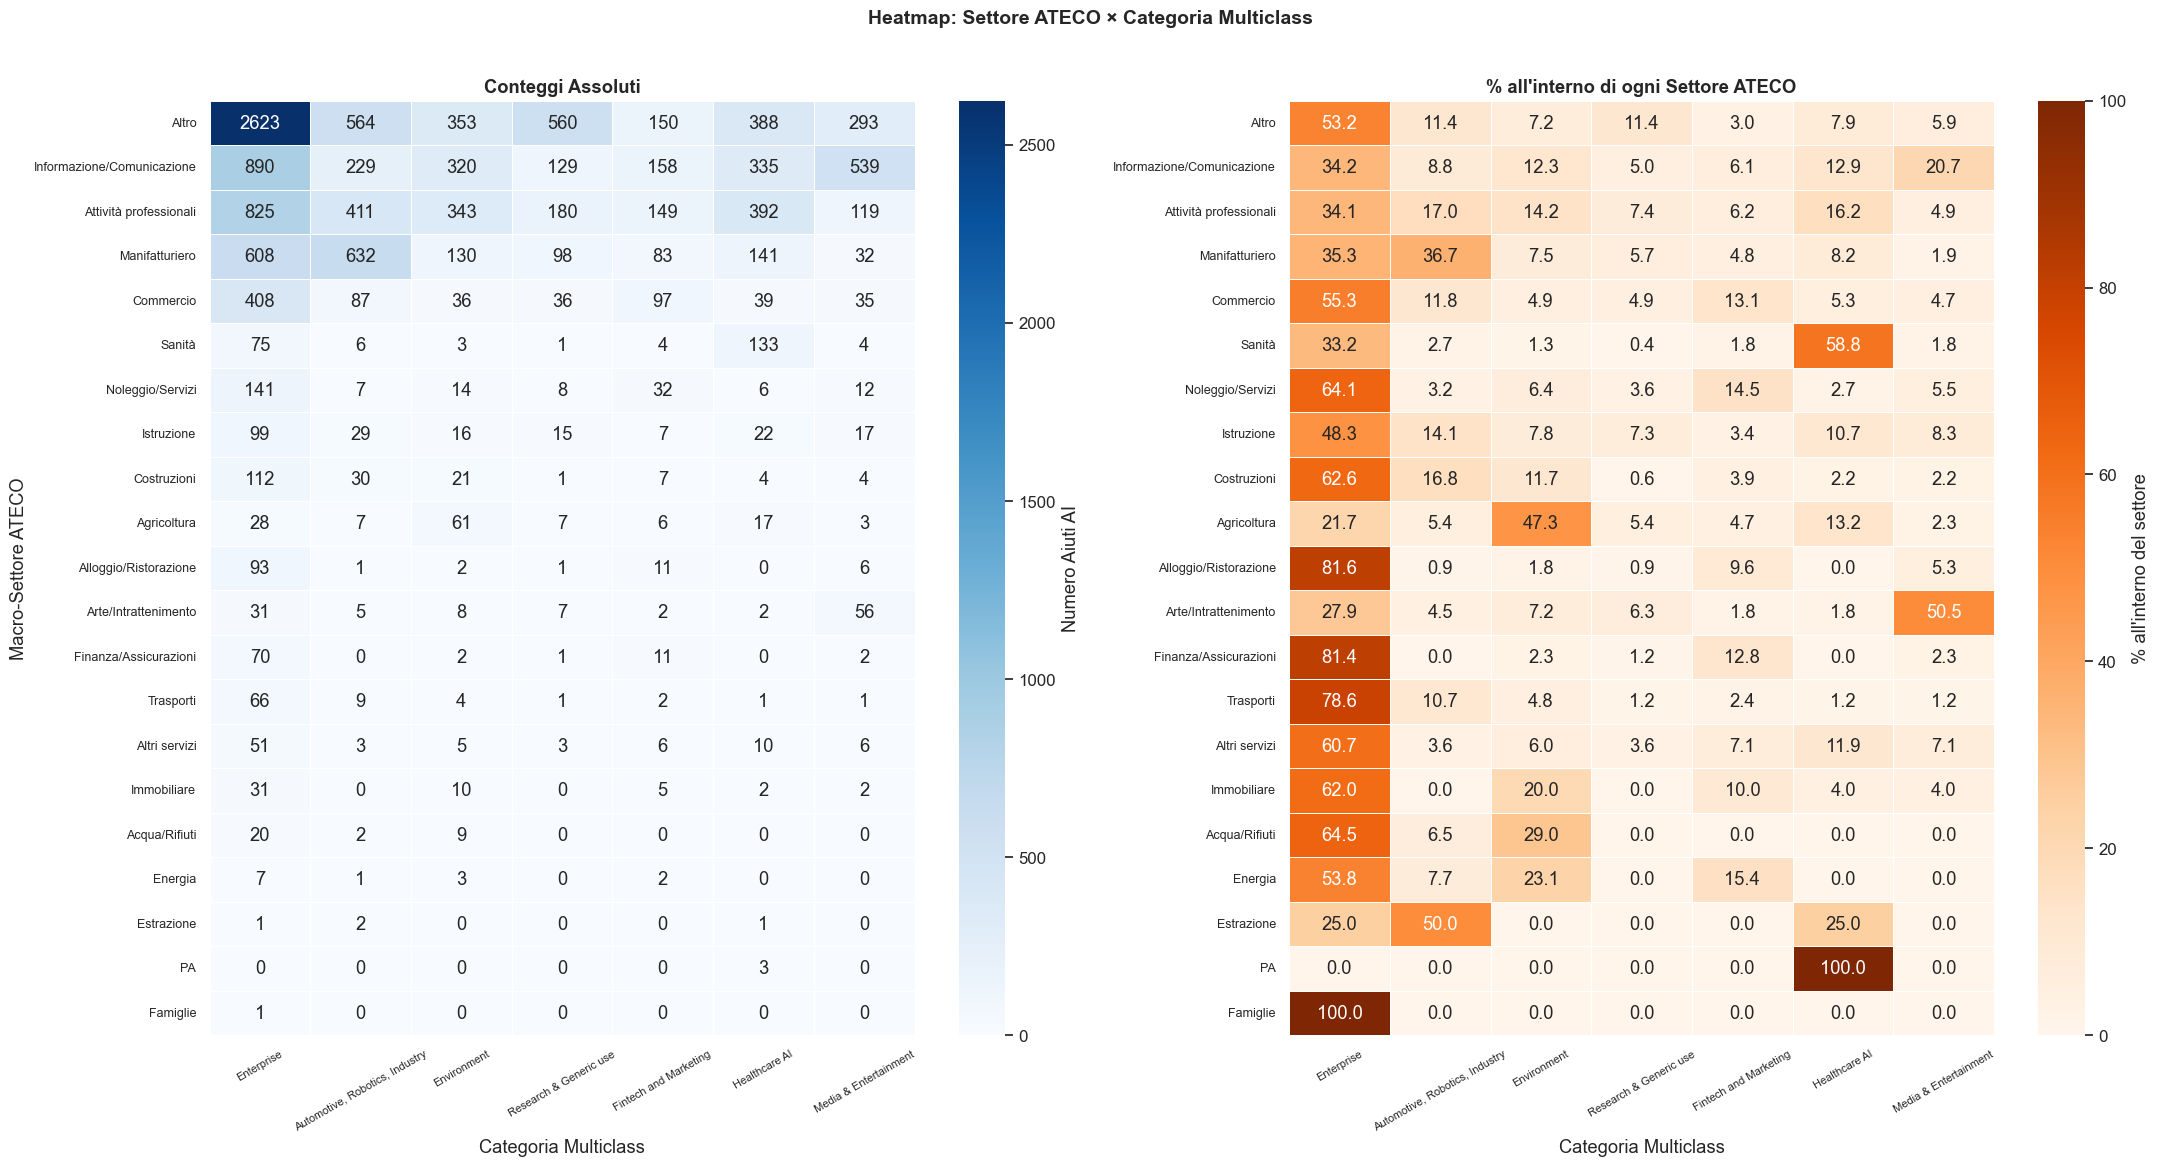

In [16]:
# Heatmap: ATECO macro-settore × categoria multiclass
df_ai_mc2 = df_ai[df_ai['CLASSIFICAZIONE_MULTICLASS'].notna()].copy()
df_ai_mc2['SETTORE_NOME_MC'] = df_ai_mc2['SETTORE_MACRO'].map(ATECO_SEZIONI).fillna('Altro')

hm_ateco = (
    df_ai_mc2.groupby(['SETTORE_NOME_MC', 'CLASSIFICAZIONE_MULTICLASS'])
    .size()
    .unstack(fill_value=0)
)
ordered_mc_cols2 = [c for c in MULTICLASS_CATEGORIES if c in hm_ateco.columns]
hm_ateco = hm_ateco[ordered_mc_cols2]
# Escludi settori con zero totale
hm_ateco = hm_ateco.loc[hm_ateco.sum(axis=1) > 0]
# Ordina per totale decrescente
hm_ateco = hm_ateco.loc[hm_ateco.sum(axis=1).sort_values(ascending=False).index]

fig, axes = plt.subplots(1, 2, figsize=(22, max(7, len(hm_ateco) * 0.55)))

# Assoluti
sns.heatmap(
    hm_ateco,
    annot=True, fmt='d', cmap='Blues',
    linewidths=0.4, ax=axes[0],
    cbar_kws={'label': 'Numero Aiuti AI'}
)
axes[0].set_title('Conteggi Assoluti', fontweight='bold')
axes[0].set_xlabel('Categoria Multiclass')
axes[0].set_ylabel('Macro-Settore ATECO')
axes[0].tick_params(axis='x', rotation=30, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

# Normalizzata per riga (%)
hm_ateco_pct = hm_ateco.div(hm_ateco.sum(axis=1), axis=0) * 100

sns.heatmap(
    hm_ateco_pct,
    annot=True, fmt='.1f', cmap='Oranges',
    linewidths=0.4, ax=axes[1],
    cbar_kws={'label': "% all'interno del settore"}
)
axes[1].set_title("% all'interno di ogni Settore ATECO", fontweight='bold')
axes[1].set_xlabel('Categoria Multiclass')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=9)

fig.suptitle('Heatmap: Settore ATECO × Categoria Multiclass', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Analisi Regionale Quantitativa

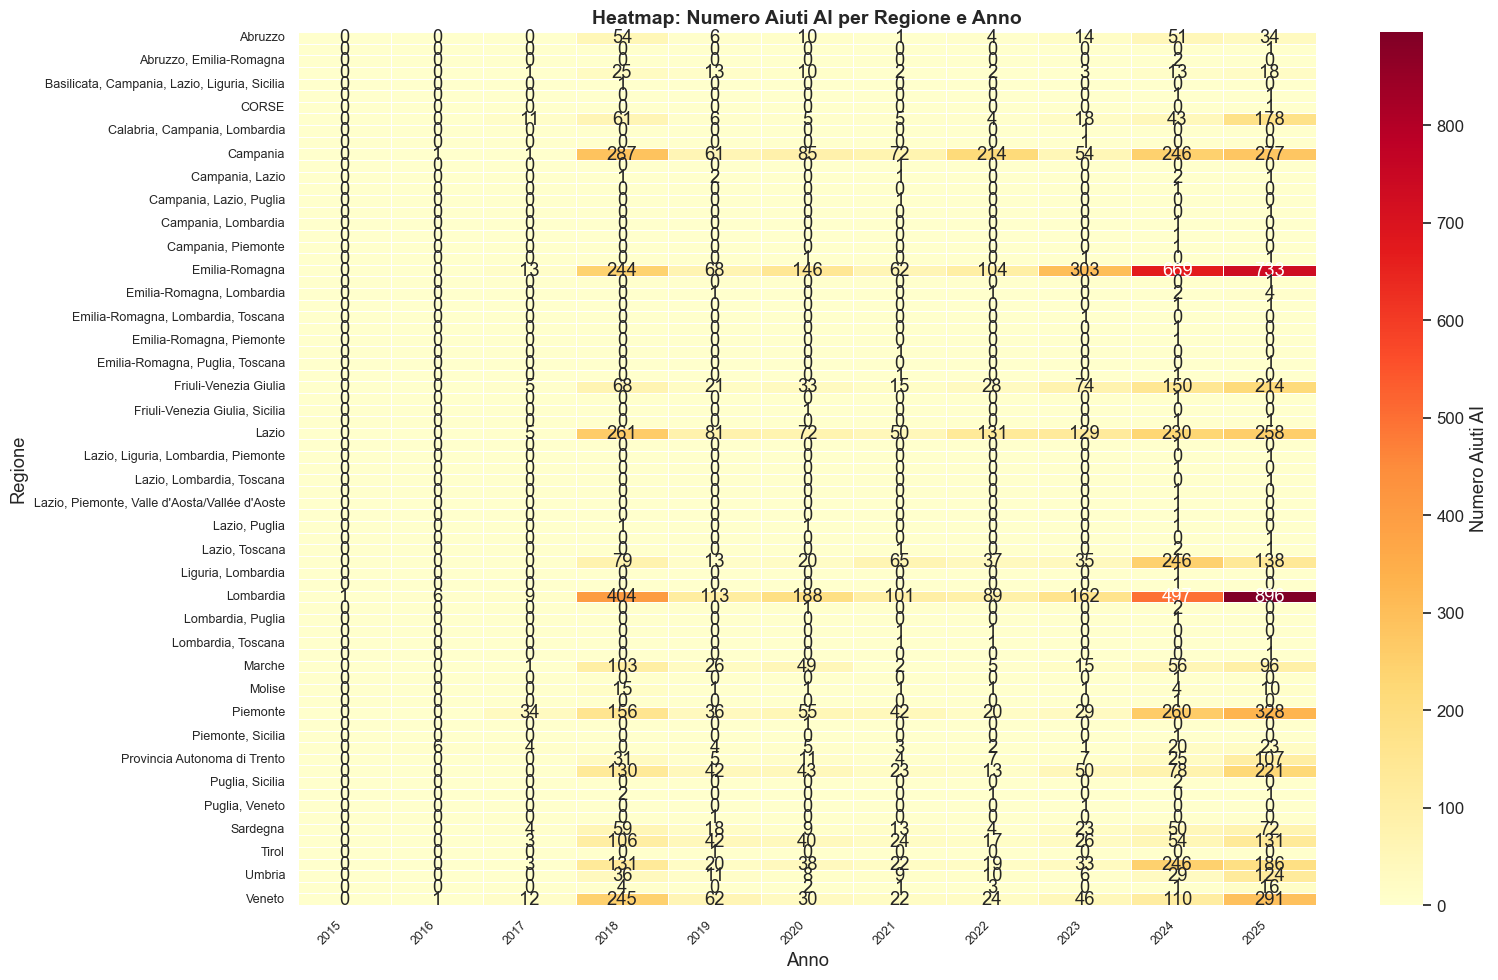

In [17]:
# Heatmap: Regione × Anno — numero aiuti AI
if len(df_ai) > 0:
    heatmap_data = df_ai.groupby(['REGIONE_BENEFICIARIO', 'ANNO']).size().unstack(fill_value=0)
    
    fig, ax = plt.subplots(figsize=(16, 10))
    sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
                ax=ax, cbar_kws={'label': 'Numero Aiuti AI'})
    ax.set_title('Heatmap: Numero Aiuti AI per Regione e Anno', fontsize=14, fontweight='bold')
    ax.set_xlabel('Anno')
    ax.set_ylabel('Regione')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

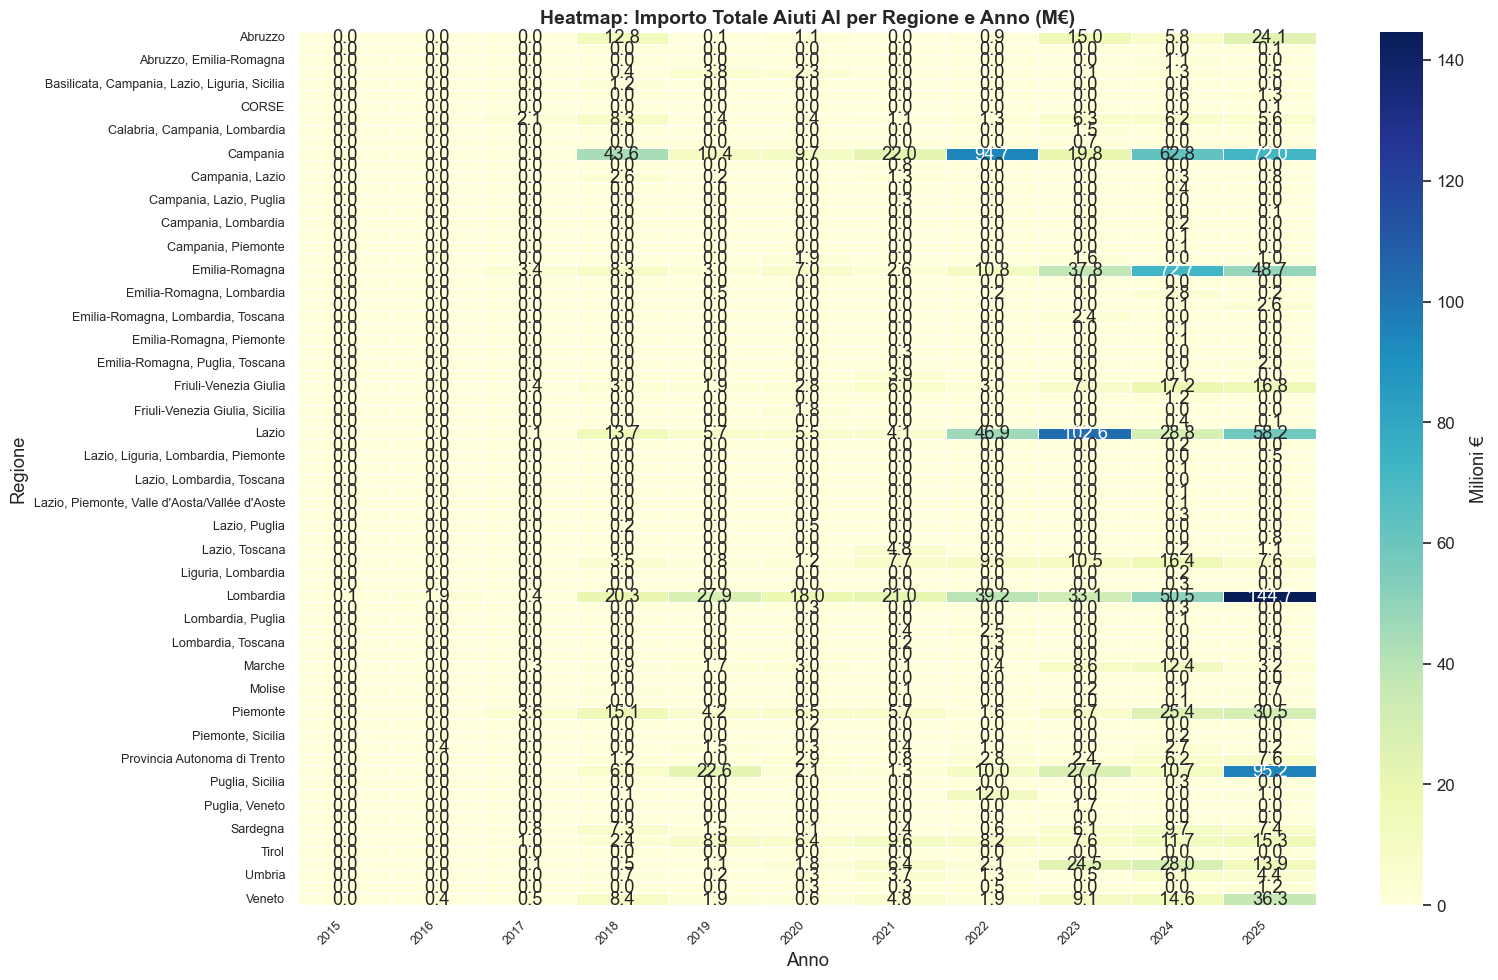

In [18]:
# Heatmap: Regione × Anno — importo totale AI (milioni €)
if len(df_ai) > 0:
    heatmap_importi = (df_ai.groupby(['REGIONE_BENEFICIARIO', 'ANNO'])['IMPORTO_NOMINALE_TOTALE']
                       .sum().unstack(fill_value=0) / 1e6)
    
    fig, ax = plt.subplots(figsize=(16, 10))
    sns.heatmap(heatmap_importi, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5,
                ax=ax, cbar_kws={'label': 'Milioni €'})
    ax.set_title('Heatmap: Importo Totale Aiuti AI per Regione e Anno (M€)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Anno')
    ax.set_ylabel('Regione')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

### 6.1 Heatmap Regione × Categoria Multiclass

Regioni e categorie con zero record in entrambe le dimensioni sono escluse per leggibilità.

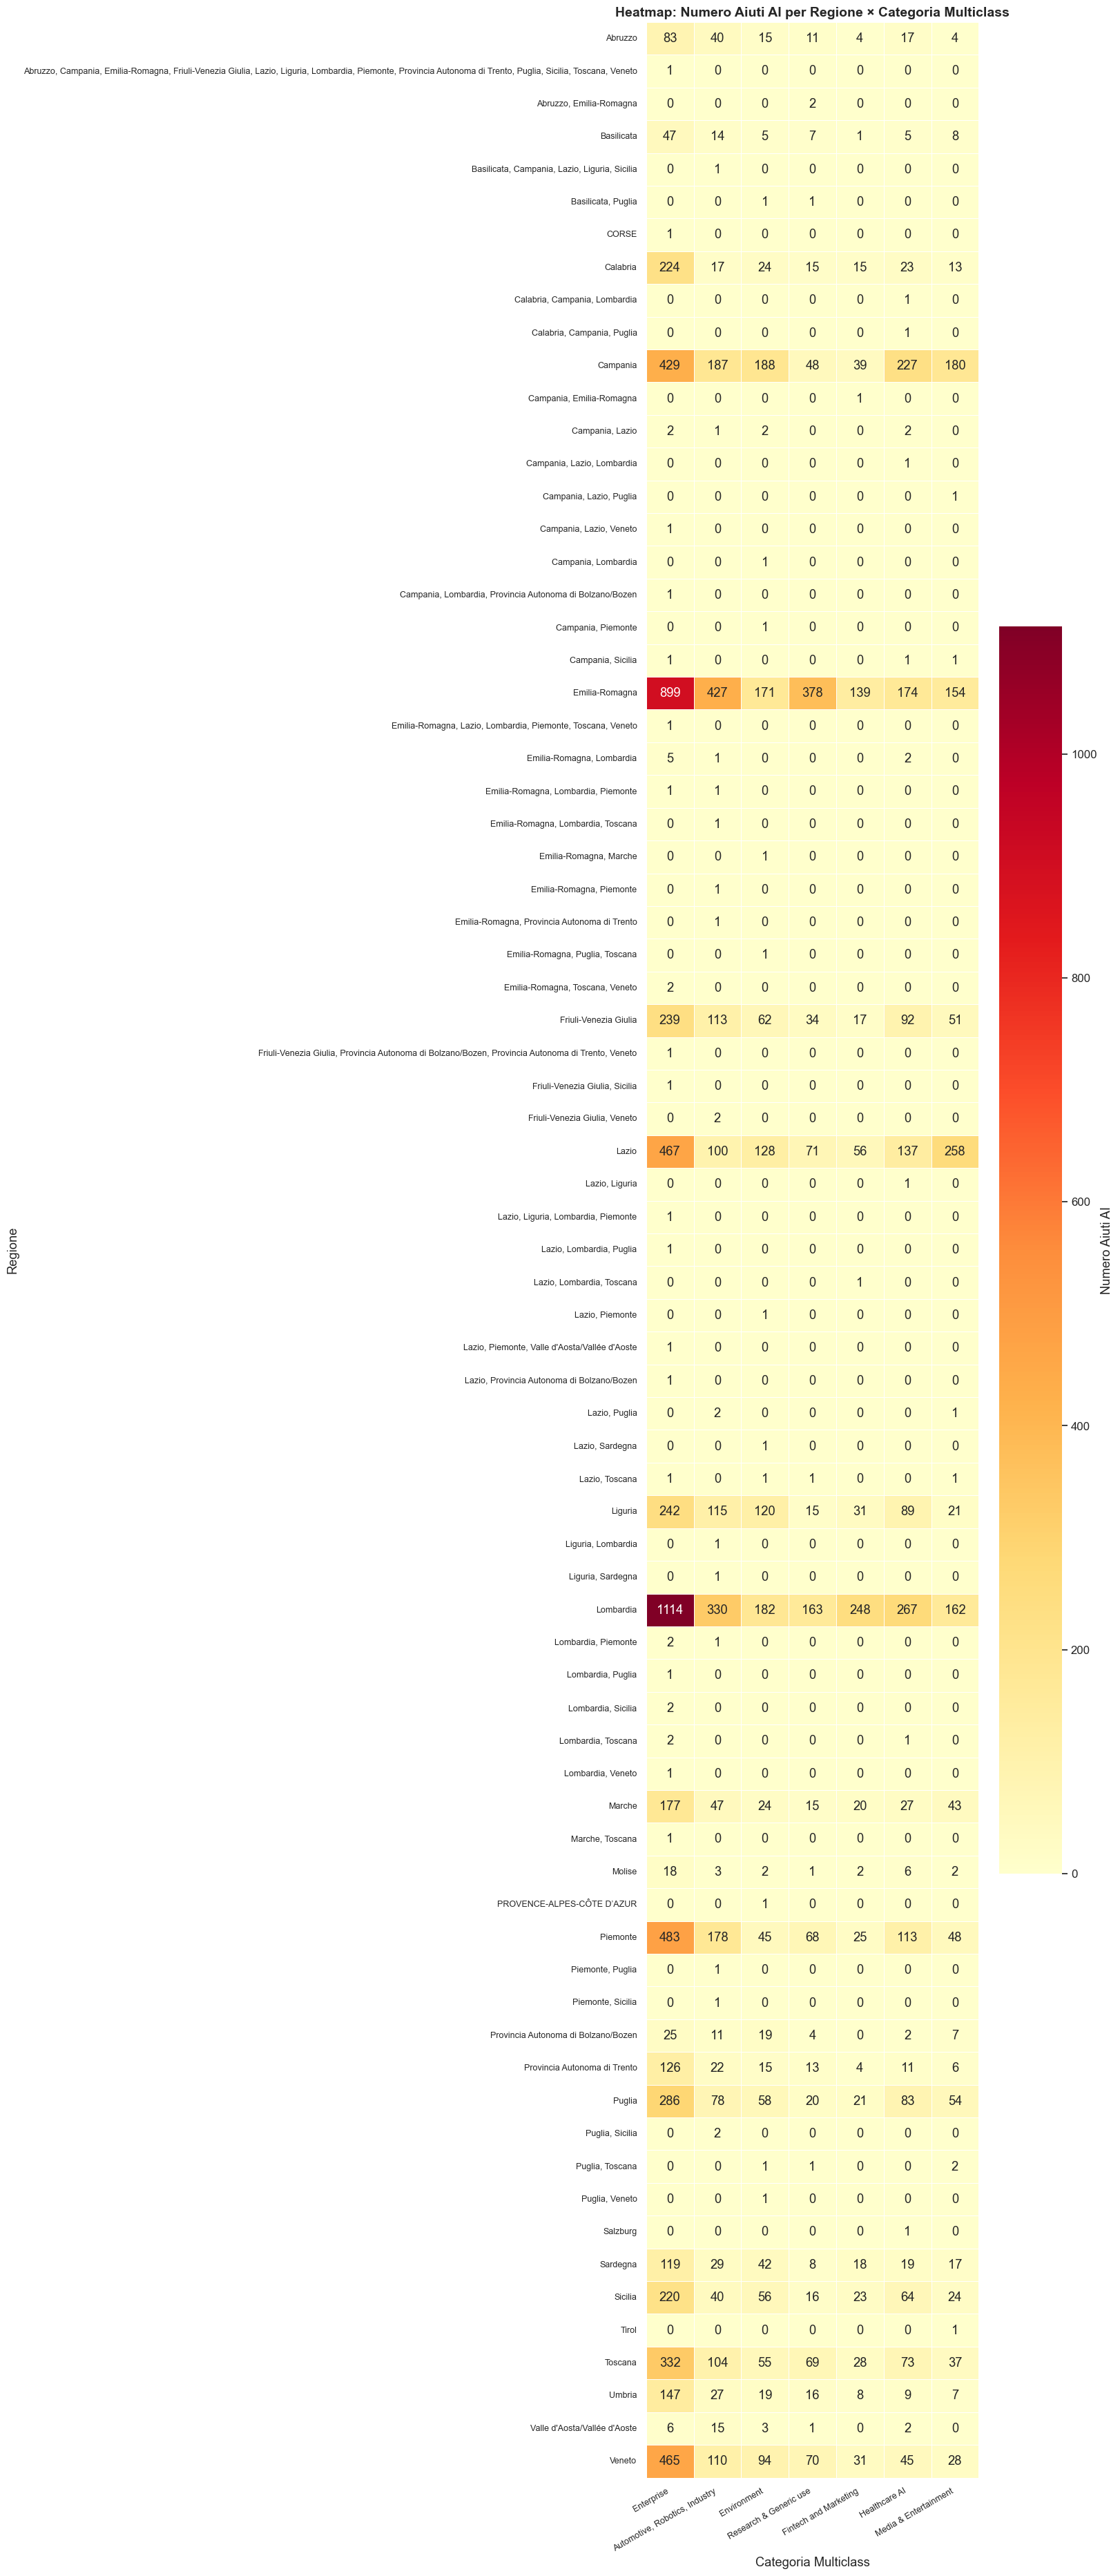

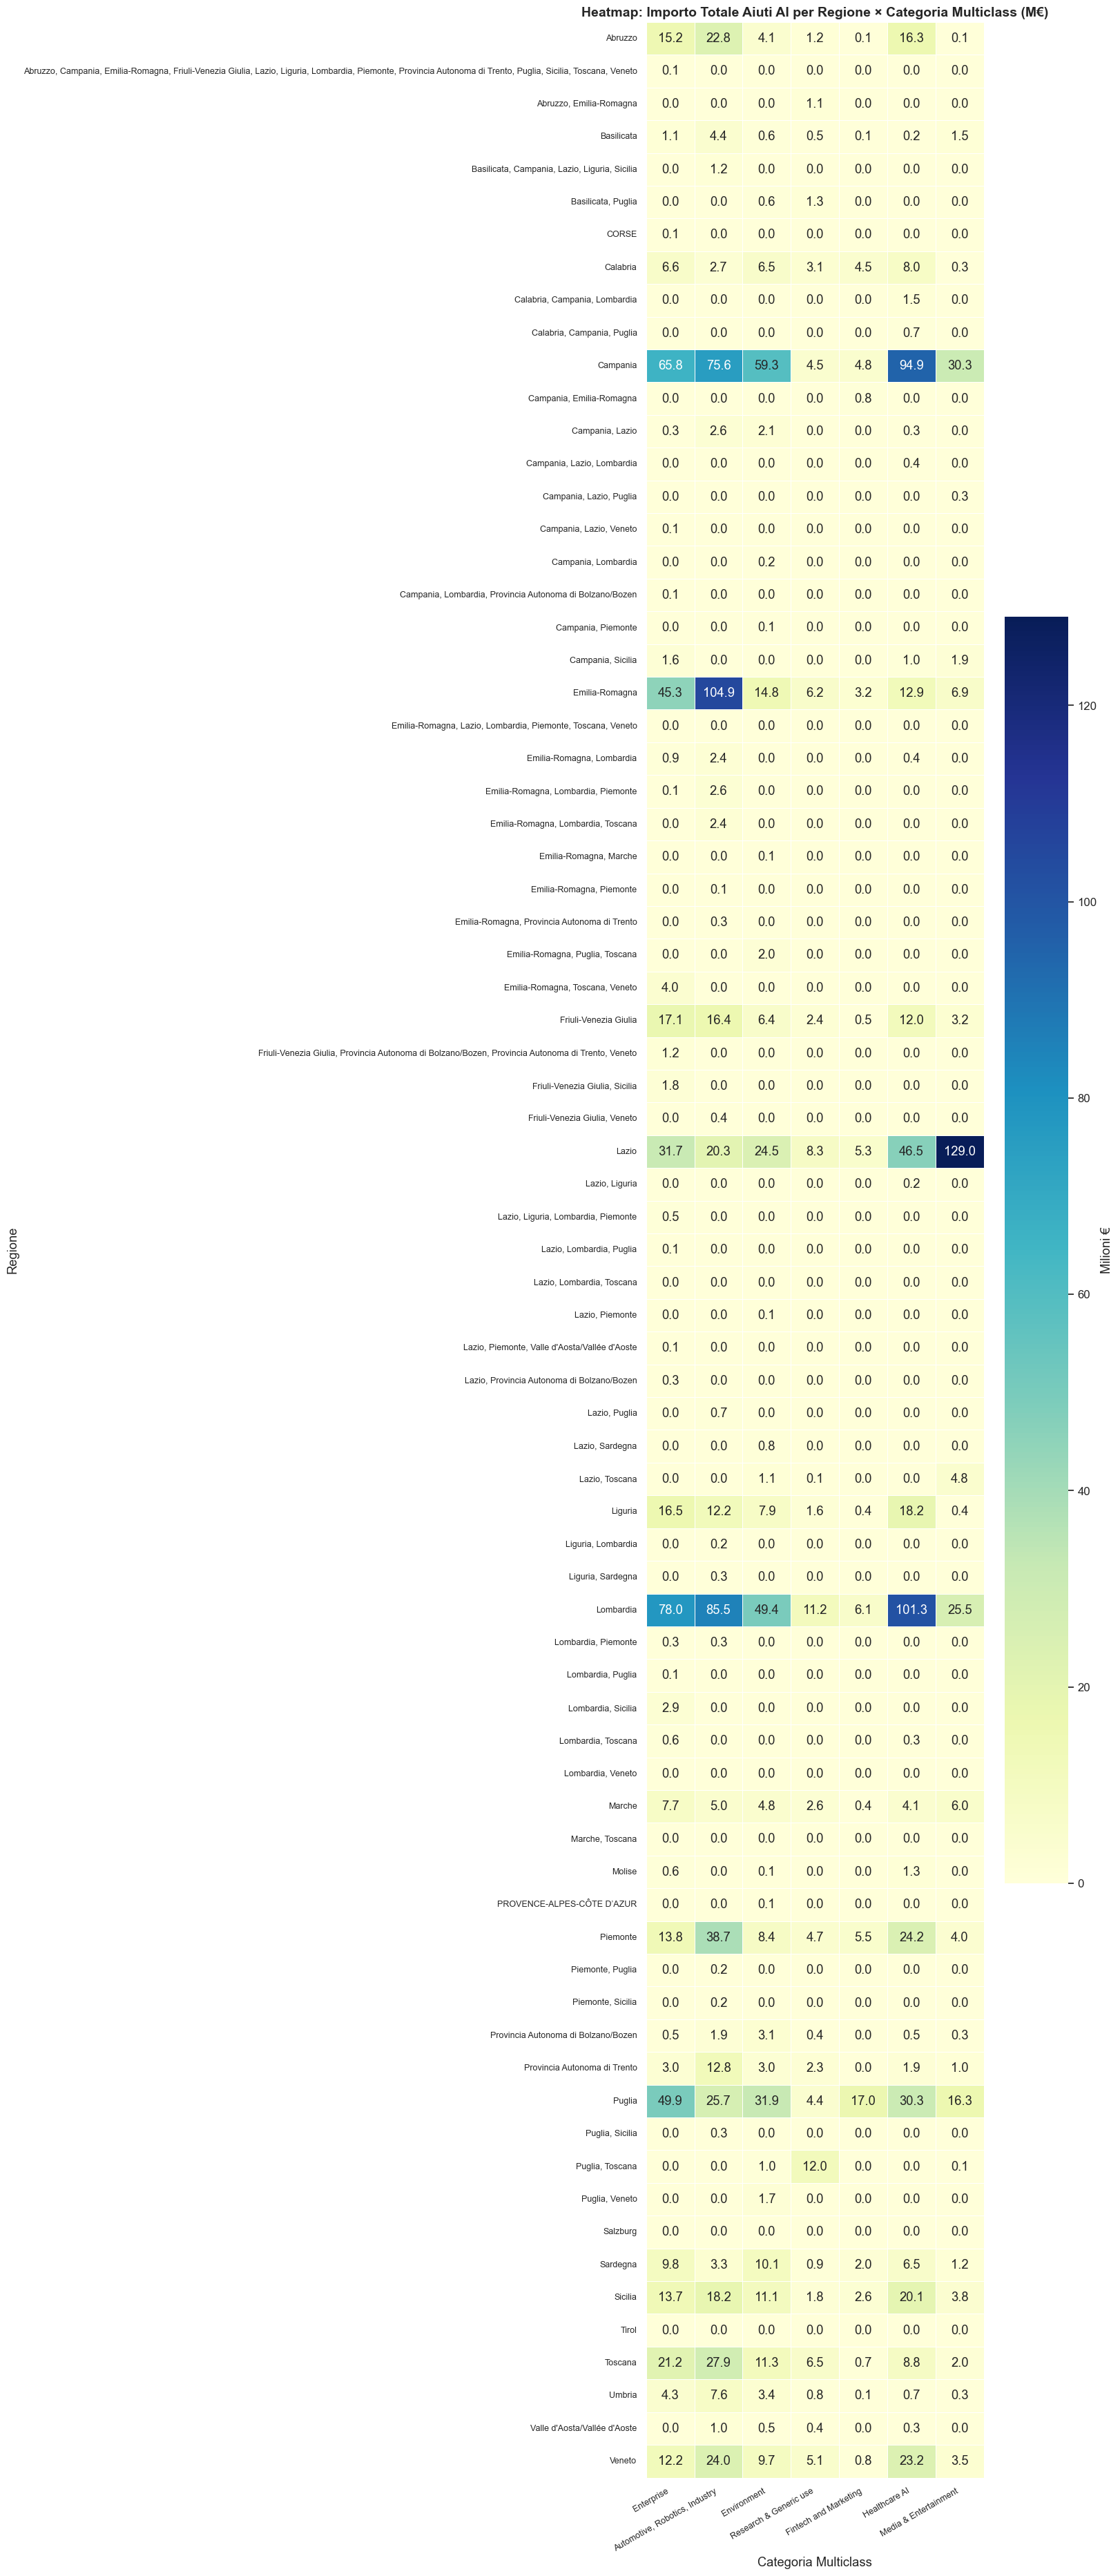

In [19]:
# Heatmap: Regione × Categoria — numero aiuti AI
df_ai_mc = df_ai[df_ai['CLASSIFICAZIONE_MULTICLASS'].notna()].copy()

hm_reg_count = (
    df_ai_mc.groupby(['REGIONE_BENEFICIARIO', 'CLASSIFICAZIONE_MULTICLASS'])
    .size()
    .unstack(fill_value=0)
)
# Riordina colonne canonico, escludi righe tutto-zero
ordered_mc_cols = [c for c in MULTICLASS_CATEGORIES if c in hm_reg_count.columns]
hm_reg_count = hm_reg_count[ordered_mc_cols]
hm_reg_count = hm_reg_count.loc[hm_reg_count.sum(axis=1) > 0]

fig, ax = plt.subplots(figsize=(16, max(8, len(hm_reg_count) * 0.5)))
sns.heatmap(
    hm_reg_count,
    annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Numero Aiuti AI'}
)
ax.set_title('Heatmap: Numero Aiuti AI per Regione × Categoria Multiclass', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoria Multiclass')
ax.set_ylabel('Regione')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Heatmap: Regione × Categoria — importo totale AI (M€)
hm_reg_imp = (
    df_ai_mc.groupby(['REGIONE_BENEFICIARIO', 'CLASSIFICAZIONE_MULTICLASS'])['IMPORTO_NOMINALE_TOTALE']
    .sum()
    .unstack(fill_value=0)
) / 1e6
hm_reg_imp = hm_reg_imp[ordered_mc_cols]
hm_reg_imp = hm_reg_imp.loc[hm_reg_imp.sum(axis=1) > 0]

fig, ax = plt.subplots(figsize=(16, max(8, len(hm_reg_imp) * 0.5)))
sns.heatmap(
    hm_reg_imp,
    annot=True, fmt='.1f', cmap='YlGnBu',
    linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Milioni €'}
)
ax.set_title('Heatmap: Importo Totale Aiuti AI per Regione × Categoria Multiclass (M€)', fontsize=14, fontweight='bold')
ax.set_xlabel('Categoria Multiclass')
ax.set_ylabel('Regione')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## 7. Tipo di Beneficiario

In [20]:
# Distribuzione per tipo di beneficiario
tipo_class = df.groupby(['DES_TIPO_BENEFICIARIO', 'CLASSIFICAZIONE']).size().unstack(fill_value=0)
if 'AI' in tipo_class.columns:
    tipo_class['% AI'] = (tipo_class['AI'] / tipo_class.sum(axis=1) * 100).round(3)
    tipo_class = tipo_class.sort_values('AI', ascending=False)

tipo_class

CLASSIFICAZIONE,AI,NON_AI,UNKNOWN,% AI
DES_TIPO_BENEFICIARIO,,,,
PMI,12491,22395088,4,0.056
Grande impresa,1159,164210,0,0.701
-,302,13100,0,2.253
Non classificata,0,1375919,0,0.000


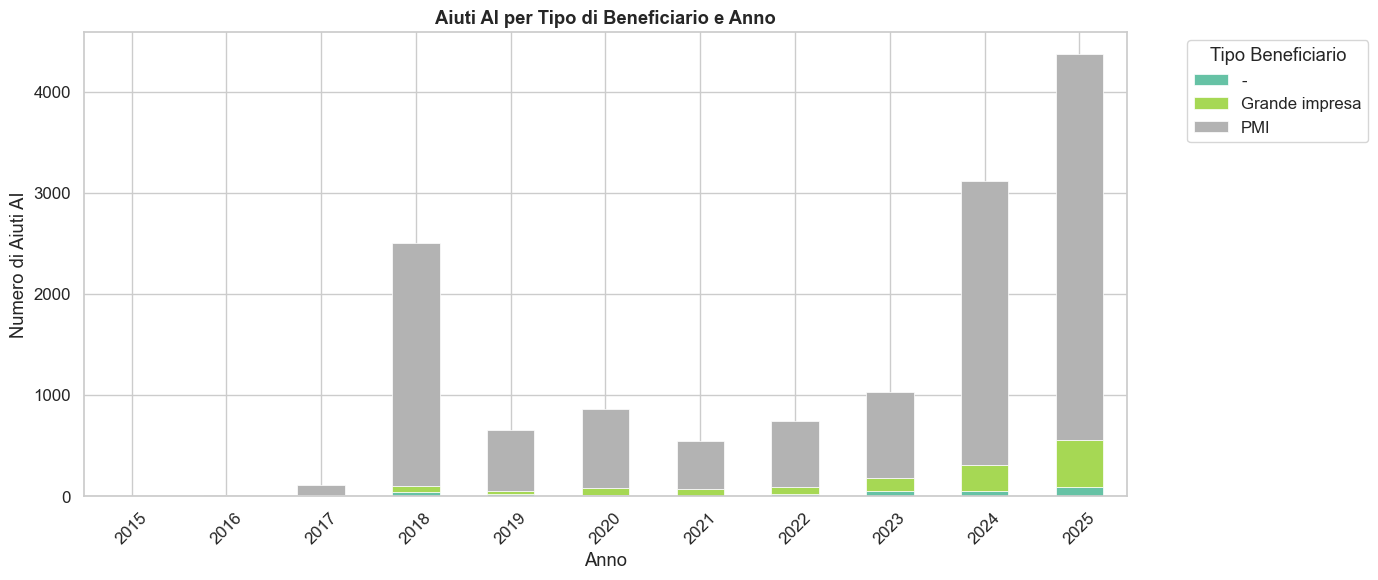

In [21]:
# Grafico tipo beneficiario per AI
if len(df_ai) > 0:
    tipo_ai_year = (df_ai.groupby(['ANNO', 'DES_TIPO_BENEFICIARIO']).size()
                    .unstack(fill_value=0))
    
    fig, ax = plt.subplots(figsize=(14, 6))
    tipo_ai_year.plot(kind='bar', stacked=True, ax=ax, 
                      colormap='Set2', edgecolor='white', linewidth=0.5)
    ax.set_title('Aiuti AI per Tipo di Beneficiario e Anno', fontweight='bold')
    ax.set_xlabel('Anno')
    ax.set_ylabel('Numero di Aiuti AI')
    ax.legend(title='Tipo Beneficiario', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

### 7.1 Tipo di Beneficiario × Categoria Multiclass

Grouped bar: distribuzione delle 7 categorie multiclass per tipo di beneficiario (PMI / Grande impresa / Altro).

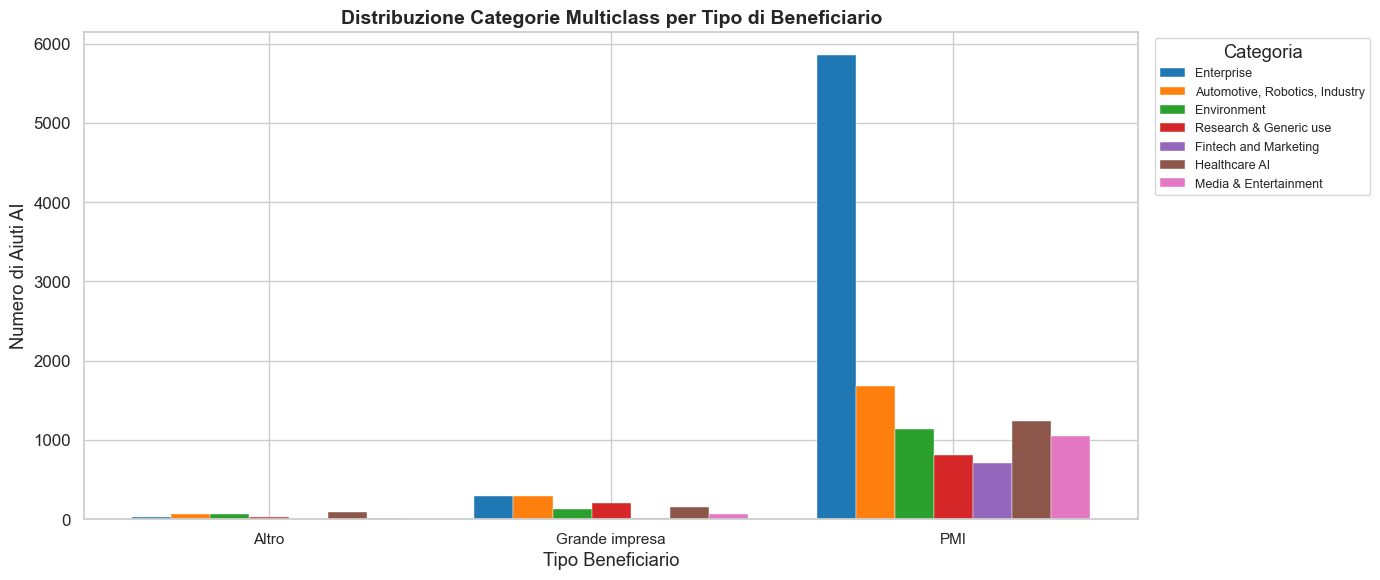

In [22]:
# Grouped bar: tipo beneficiario × categoria multiclass
# Raggruppa in PMI / Grande impresa / Altro
def normalizza_tipo(t):
    t = str(t).strip().upper()
    if 'PMI' in t or 'PICCOLA' in t or 'MEDIA' in t:
        return 'PMI'
    elif 'GRANDE' in t:
        return 'Grande impresa'
    else:
        return 'Altro'

df_ai_tipo = df_ai.copy()
df_ai_tipo['TIPO_NORM'] = df_ai_tipo['DES_TIPO_BENEFICIARIO'].apply(normalizza_tipo)

tipo_mc = (
    df_ai_tipo[df_ai_tipo['CLASSIFICAZIONE_MULTICLASS'].notna()]
    .groupby(['TIPO_NORM', 'CLASSIFICAZIONE_MULTICLASS'])
    .size()
    .unstack(fill_value=0)
)

# Riordina colonne canonico
ordered_mc_cols3 = [c for c in MULTICLASS_CATEGORIES if c in tipo_mc.columns]
tipo_mc = tipo_mc[ordered_mc_cols3]

x = np.arange(len(tipo_mc.index))
n_cats = len(ordered_mc_cols3)
bar_width = 0.8 / n_cats

fig, ax = plt.subplots(figsize=(14, 6))
for i, cat in enumerate(ordered_mc_cols3):
    offsets = x + (i - n_cats / 2 + 0.5) * bar_width
    ax.bar(
        offsets, tipo_mc[cat].values,
        width=bar_width,
        label=cat,
        color=MULTICLASS_COLOR_MAP[cat],
        edgecolor='white',
        linewidth=0.3
    )

ax.set_xticks(x)
ax.set_xticklabels(tipo_mc.index, fontsize=11)
ax.set_title('Distribuzione Categorie Multiclass per Tipo di Beneficiario', fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo Beneficiario')
ax.set_ylabel('Numero di Aiuti AI')
ax.legend(title='Categoria', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Riepilogo

In questo notebook abbiamo approfondito:
- Il **trend temporale** degli aiuti AI (crescita/decrescita)
- L'**evoluzione finanziaria** degli importi AI
- La **concentrazione** degli importi (Gini e Lorenz)
- La distribuzione per **settore ATECO** e **regione**
- Il profilo dei **beneficiari** (PMI vs grandi imprese)

Per analisi qualitative e testuali → **03_analisi_qualitativa.ipynb**